### Helpful resources:
* [Guide to Markdown](https://paperhive.org/help/markdown)
* [Guide to LaTeX Math symbols](http://tug.ctan.org/info/undergradmath/undergradmath.pdf)
* [Python Cheat Sheets](https://ehmatthes.github.io/pcc/cheatsheets/README.html)
* [Moving to Python from MATLAB](https://bastibe.de/2013-01-20-a-python-primer-for-matlab-users.html)


# Lab #2: The Planetary Boundary Layer
### Farhan Ariff bin Halis Azhan
### Collaborators
* Name
* Name

## Goal and Introduction
The goal of this lab is to investigate the concept of the planetary boundary layer (PBL) of the atmosphere and to use statisitcal concepts suach as
correlation and covariance to find the boundary layer between troposphere and earth' surface.

The troposhere, the region of Earth's atmosphere extending from the surface up to the tropopause, can be divided into two regions by height, which are
Planary Boundary Layer(PBL), and free atmosphere. PBL is the region closest to the surface while the region above PBL is another region called free 
atmosphere. Initially, air temperature will drop with increase in altitude, then increase slightly at the PBL, and continue dropping after 
PBL. The characteristic of the air temperature (out of many other atmospheric constituent) are usually highly correlated within the same region,
but weakly correlated within different regions.

In this lab, we will use that weak correlation between different region property to find in what altitude (in km) PBL will start.

## Data
The dataset that will be used is WV-profiles.csv. This datasets consist of 30 rows and 21 columns, with the first column represent altitude (in km)
while the other 20 columns represent the 20 samples' water vapor profiles.
There will be no cleaning procress for this data.

----

## Approach and Results
Describe your approach for each question in the lab description and interpretation of the results for that question.
Start with an over-arching paragraph to describe your approach as you see fit.

In [18]:
# Import critical libraries:
import numpy as np
import matplotlib.pyplot as plt

# Turn on in-line plotting:
%matplotlib inline

### Question 1
Load the data into a Numpy array by using genfromtxt.  
Confirm that the data imported correctly.  
Unlike previous labs, do not use names=, just load the data into a
single two-dimensional array.  
See the information above for details.


In [19]:
# read csv file
data = np.genfromtxt('./WV-profiles.csv', delimiter=",", skip_header=5)
# print the shape of data
print(data.shape)

(30, 21)


In [20]:
# Testing if the data imported correctly
# check if the first column first row is 0.5
print(data[0,0])
print(data[0,0] == 0.5)
# check if the first column last row is 15.0
print(data[-1,0])
print(data[-1,0] == 15.0)

0.5
True
15.0
True


### Question 2
Examine the amount of variability between profiles. 

Generate a line plot (not a scatter plot) that shows all 20 water vapor profiles on a single axes. 

Plot altitude (z) on the vertical axis and the 20 profiles of water vapor density (ρ) on the horizontal axis. 

On a separate axes, plot the mean and standard deviation of ρ as a function of altitude. 

In other words, what is the mean and standard deviation of the 20 profiles at each altitude?


Describe the characteristics of the water vapor in the atmosphere.


In [21]:
# Plot altitude (z) on the vertical axis and the 20 profiles of water vapor density (ρ) on the horizontal axis. 
# assign altitude column into alt variable
alt = data[:,0]
# assign 20 samples column into wv (short for water vapor) variable
rho = data[:,1:]
# check if the shape holds true
# print(alt.shape)
# print(rho.shape)

Text(0, 0.5, 'Altitude (km)')

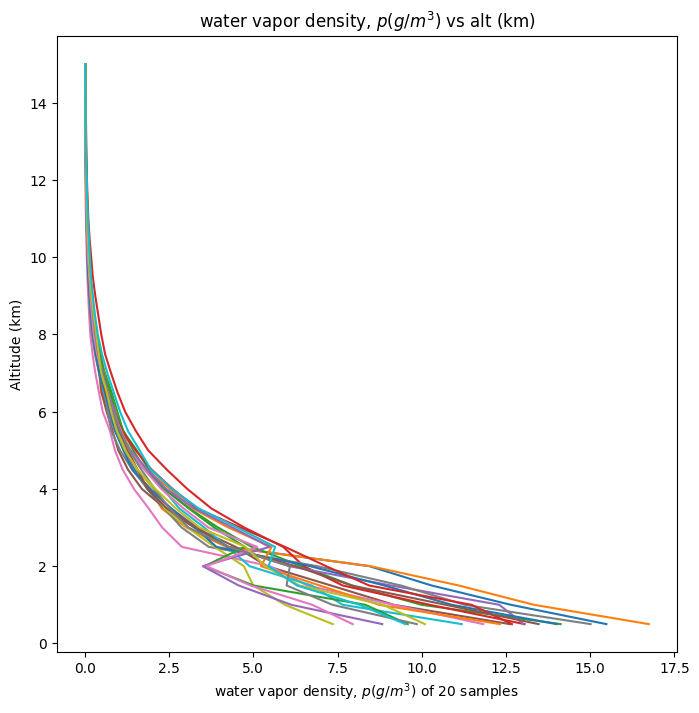

In [22]:
# Initialize a figure of size 1,1 (default) with size 8,8
orig_fig = plt.figure(figsize=(8,8))
orig_axe = orig_fig.subplots(1)
# x-axis is rho (water density) and y-axis is altitude(km)
orig_axe.plot(rho, alt)
# giving title and labels to x axis and y axis
orig_axe.set_title(f"water vapor density, $p (g/m^{3})$ vs alt (km)")
orig_axe.set_xlabel(f"water vapor density, $p (g/m^{3})$ of 20 samples")
orig_axe.set_ylabel(f"Altitude (km)")

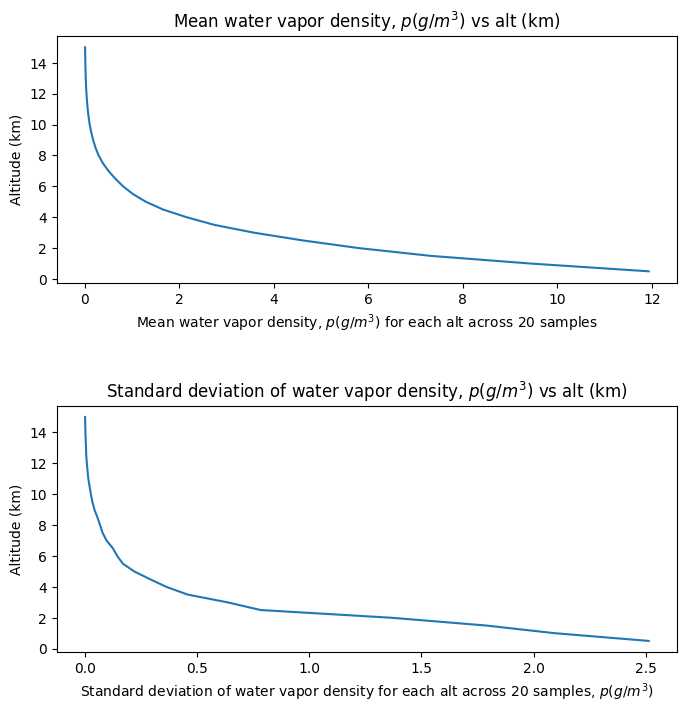

In [23]:
# plot the mean and standard deviation of ρ as a function of altitude. The figure consist of 2 axes and figure size of (8,8)
data_fig = plt.figure(figsize=(8,8))
mean_axe, std_axe = data_fig.subplots(2)
# mean axis
mean_axe.plot(rho.mean(axis=1), alt)
mean_axe.set_title(f"Mean water vapor density, $p (g/m^{3})$ vs alt (km)")
mean_axe.set_xlabel(f"Mean water vapor density, $p (g/m^{3})$ for each alt across 20 samples")
mean_axe.set_ylabel(f"Altitude (km)")
# standard deviation axis
std_axe.plot(rho.std(axis=1), alt)
std_axe.set_title(f"Standard deviation of water vapor density, $p (g/m^{3})$ vs alt (km)")
std_axe.set_xlabel(f"Standard deviation of water vapor density for each alt across 20 samples, $p (g/m^{3})$")
std_axe.set_ylabel(f"Altitude (km)")
plt.subplots_adjust(hspace = 0.5)

#### Describe the characteristics of the water vapor in the atmosphere

The first figure shows the 20 samples' water density across altitude between 0.5 km to 15.km, with varying initial values. From the figure, the water vapor density decrease as the altitude increase, and this behaviour was similar across 20 samples, until it hit altitude of 15 (in km) and its water vapor density was similar across the 20 samples. There is capping inversion of water vapor density at altitude 2.


The second axis shows there is high mean of water vapor density (its mean value is 12 across 20 samples) at lower altitute, and it keeps decreasing as the altitude increase. Thus, the relationship between mean water vapor density and alt (in km) is inverse relationship.
The mean of water vapor density decrease as the altitude increase, and there is a spike of decrease in mean in between alt of 2 and 6.

The third axis shows there is high standard deviation of water vapor density (its standard deviation value 2.5 across 20 samples) at lower altitute, and it keeps decreasing as the altitude increase. Thus, the relationship between standard deviation of water vapor density and alt (in km) is inverse relationship.
The standard deviation of water vapor density decrease as the altitude increase, and there is a spike of decrease in mean in between alt of 2 and 6.


### Question 3
Scatter plots are a good way to get a feel for the relative correlation between two
signals. 

Compare the 20 values of water vapor at one level to 20 values of water vapor at
another level. 

These plots should indicate how much variation in the water vapor density
at two levels in the atmosphere are related. For example, if the density increases at 10 km,
how likely is it that it also increased at 1 km and are the degrees of increase related?

Generate scatter plots for the following pairs of heights:  
· 0.5 km vs. 1.5 km  
· 0.5 km vs. 5.0 km  
· 0.5 km vs. 15.0 km  
· 1.5 km vs. 5.0 km  
· 5.0 km vs. 15.0 km  
· 10.0 km vs. 15.0 km  

Properly label and title each plot. 

Visually assess the correlation between the datasets.

What does the correlation mean for the relationship between the two heights? 

Do these plots suggest where the boundary between the PBL and the free atmosphere may be
located?

In [24]:
# Compare the 20 values of water vapor at one level to 20 values of water vapor at another level.
# Initializing data for 0.5km, 1.5km, 5.0km, 10.0km, and 15.0km into 5 variables
# 0.5km rows
data0_5 = data[0, :] 
# 1.5km rows
data1_5 = data[2, :]
# 5.0km rows
data5_0 = data[9, :]
# 10.0km rows 
data10_0 = data[19, :]
# 15.0km rows
data15_0 = data[-1, :]

In [25]:
def make_plot(first, second):
    '''
    This function take two datasets of different altitudes that have 1 row 21 columns 
    (1 column containing alt value and 20 columns representating the 20 samples) 
    (20 columns if minus the altitude value) 
    and create a scatterplot between these 20 columns.
    
    e.g: How to use functions:
    make_plot(first_data, second_data)
    This will create a scatterplot between the datasets first_data and second_data
    '''
    fig, axe = plt.subplots(1,1, figsize=(8,8))
    axe.scatter(first[1:], second[1:])
    axe.set_title(f"water vapor density of 20 samples, $p (g/m^{3})$ between {first[0]} (in km) vs {second[0]} (in km)")
    axe.set_xlabel(f"Altitude of {first[0]} in (km)")
    axe.set_ylabel(f"Altitude of {second[0]} (in km)")

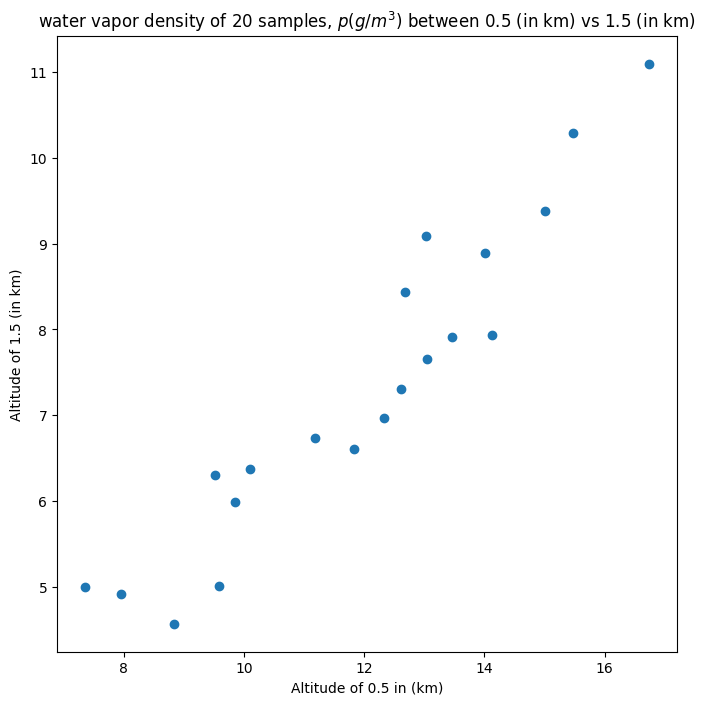

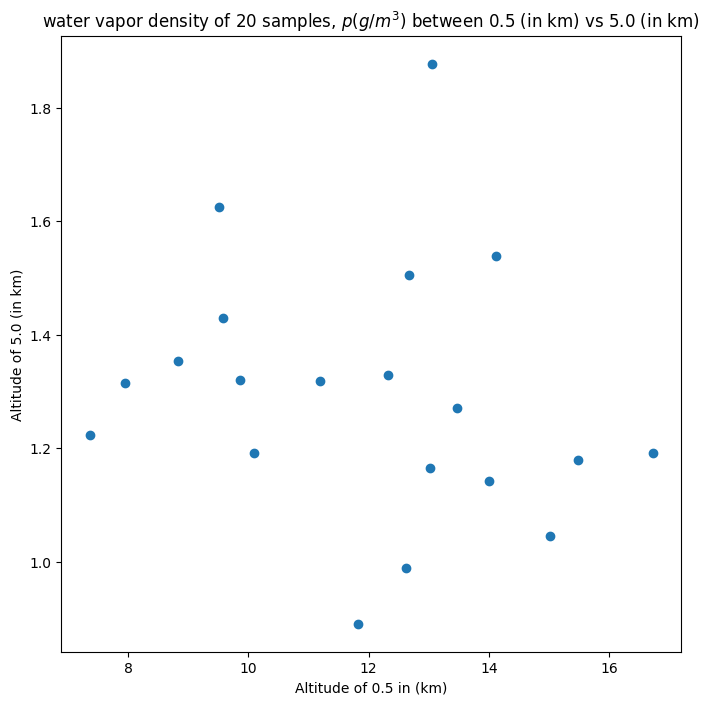

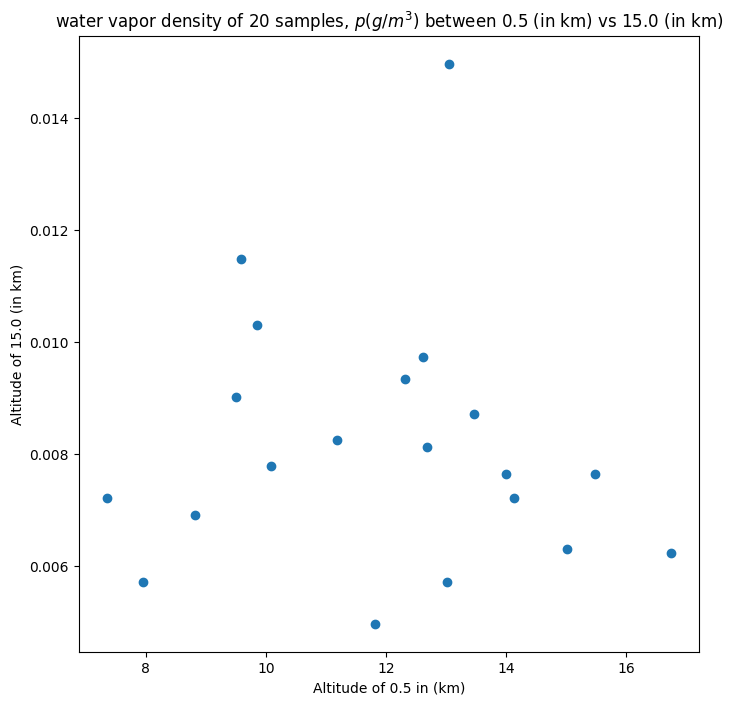

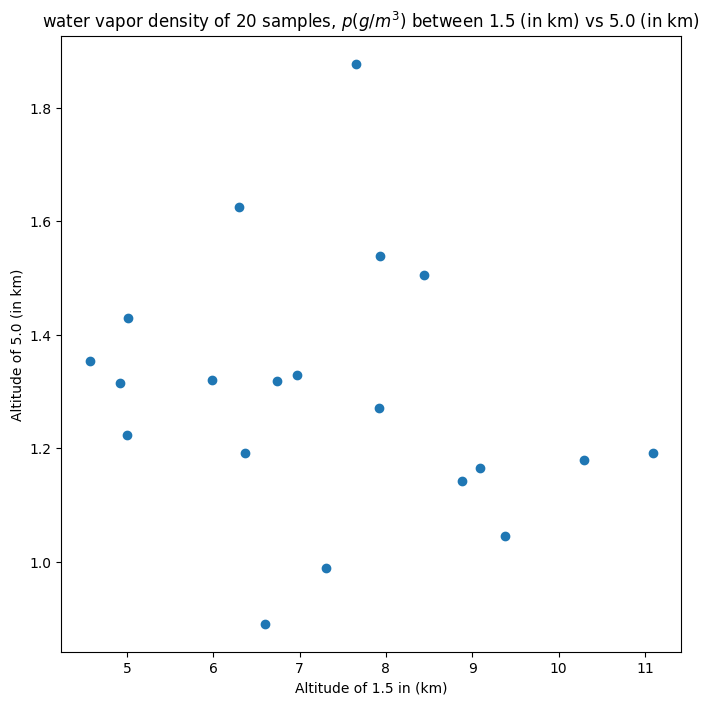

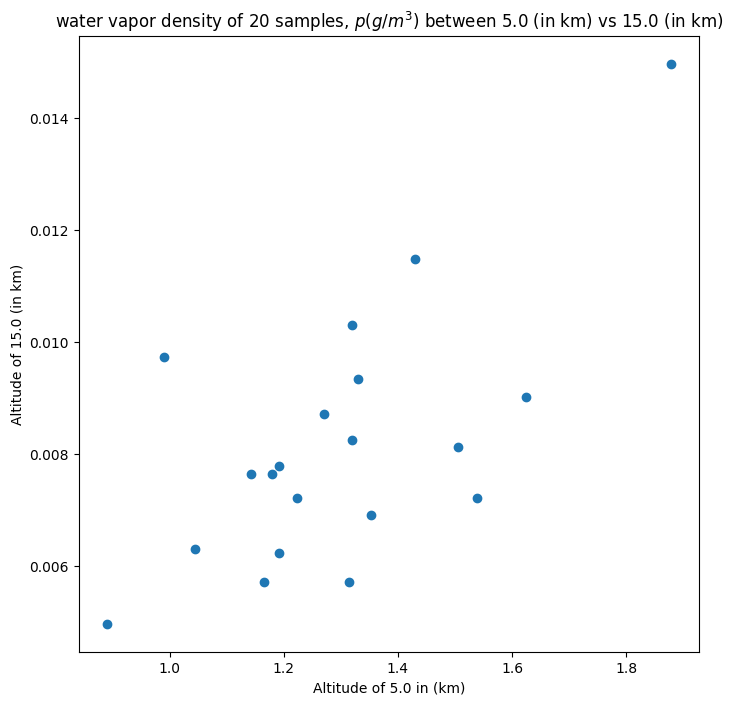

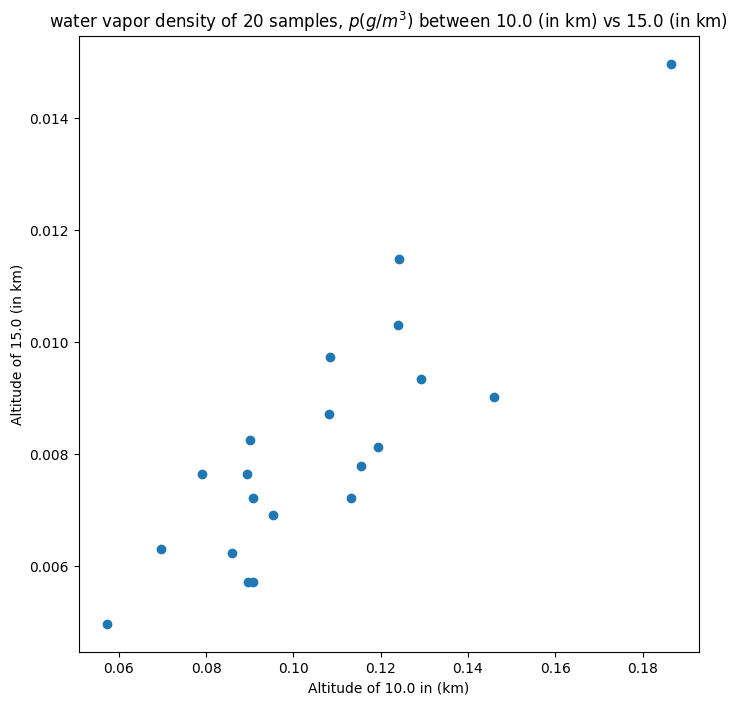

In [26]:
# 1. Make plot for 0.5km values vs 1.5km
make_plot(data0_5, data1_5)
# 2. Make plot for 0.5km values vs 5.0km
make_plot(data0_5, data5_0)
# 3. Make plot for 0.5km values vs 15.0km
make_plot(data0_5, data15_0)
# 4. Make plot for 1.5km values vs 5.0km
make_plot(data1_5, data5_0)
# 5. Make plot for 5.0km values vs 15.0km
make_plot(data5_0, data15_0)
# 6. Make plot for 10.0km values vs 15.0km
make_plot(data10_0, data15_0)

#### Visually assess the correlation between the datasets. What does the correlation mean for the relationship between the two heights? Do these plots suggest where the boundary between the PBL and the free atmosphere may be located?

The first figure (0.5km vs 1.5km) has significantly high correlation between the two altitudes.  
the second figure (0.5km vs 5.0km) has low correlation between the two altitudes.  
third figure(0.5km vs 15.0km) has significantly low correlation between the two altitudes.  
fourth figure (1.5km vs 5.0km) has low correlation between the two altitudes. 
fifth figure (5.0km vs 15.0km) has high correlation between the two altitudes.  
and sixth figure (10.0km vs 15.0km) has high correlation between the two altitudes.  

If the correlation is high between the two heights, it means that these two heights belong in the same area zone.  
The plots suggests that the boundary between the PBL and the free atmosphere might be between altitude of 1.5km and altitude of 5.0km, as these two has low correlation and the nearest distance.

### Question 4
Use numpy.corrcoef to find the pairwise correlation between each altitude. 

This will return a matrix of correlation coefficients. Generate a heatmap plot of the matrix using
the following commands:

map = plt.pcolor(altitude, altitude, corr_matrix, vmin=-1, vmax=1, cmap='Spectral_r')  

plt.colorbar(map, ax=plt.gca())

Compare this correlation matrix to the scatter plots in the previous question.  
Are these results consistent?  
Building on what you have learned about the relationship between the
PBL and the atmosphere above it, can you estimate the maximum altitude of the PBL for  
this set of water vapor density profiles?

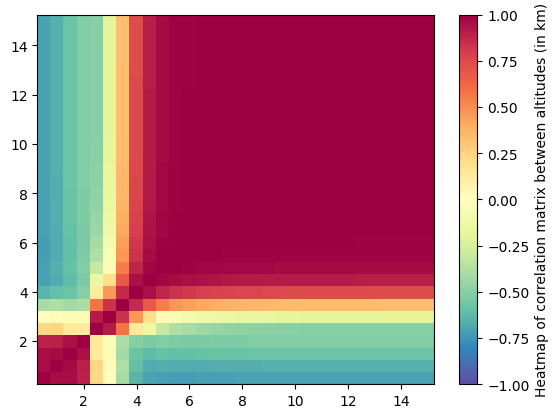

In [35]:
corr = np.corrcoef(data)
map = plt.pcolor(alt, alt, corr, vmin=-1, vmax=1, cmap='Spectral_r')
plt.colorbar(map, ax=plt.gca(), label = ("Heatmap of correlation matrix between altitudes (in km)"))
# plt.set_title("Heatmap plot of correlation matrix between altitudes")

The scatter matrix shows that low altitudes (like 0.5 and 1.5) and high altitude (like 5.0, 10.0, and 15.0)  
have high correlation when compared within the same group of altitudes (low with low or high with high),  
but have low correlation when compared within different group of altitudes (low with high).

The results are consistent, as the correlation matrix show the same behavior.  
Given that the correlation of water vapor density profiles have high correlation within the same region and low correlation between two different regions,   
we can estimate the maximum altitude of the PBL for this set of water vapor density profiles.  
The estimation of the maximum altitude of the PBL given the above heatmatrix is between altitude of 3.0.
We can estimate this by seeing the transition between yellow region (positively correlated) to bluish green region (negatively correlated), which shows where PBL starts.

## Conclusions
In conclusion, same region altitude has high correlation and different region has low altitude.  
By using this property, we can differentiate between the lower region of troposphere, PBL and upper region of troposphere, free atmoshepere, by using correlation matrix.  
Altitude that has positive correlation with each other shows that they belong in the same region and  
altitude that has negative or no correlation belong in the different region, which was shown in the heatmap above.
The transition between positive correlation and negative correlation expose where the PBL is.

## References
List any references used